# Overstimulation Bahaviour and Lifestyle Dataset


Source: __[Kaggle](https://www.kaggle.com/datasets/miadul/overstimulation-behavior-and-lifestyle-dataset)__

Columns (Features):
1. **Age**: Age of the individual (integer between 18 and 60)
2. **Sleep_Hours**: Number of hours of sleep the individual gets per day (float between 3 and 10)
3. **Screen_Time**: Total screen time (in hours) the individual spends on devices per day (float between 1 and 12)
4. **Stress_Level**: Self-reported stress level on a scale of 1 to 10 (1 = low stress, 10 = high stress)
5. **Noise_Exposure**: Frequency of exposure to high noise levels (integer between 0 and 5)
6. **Social_Interaction**: Number of social interactions per day (integer between 0 and 10)
7. **Work_Hours**: Number of hours worked per day (integer between 4 and 15)
8. **Exercise_Hours**: Number of hours spent exercising per day (float between 0 and 3)
9. **Caffeine_Intake**: Number of cups of caffeinated drinks consumed per day (integer between 0 and 5)
10. **Multitasking_Habit**: Whether the individual tends to multitask (binary: 0 = No, 1 = Yes)
11. **Anxiety_Score**: Self-reported anxiety score on a scale of 1 to 10 (1 = low anxiety, 10 = high anxiety)
12. **Depression_Score**: Self-reported depression score on a scale of 1 to 10 (1 = low depression, 10 = high depression)
13. **Sensory_Sensitivity**: Sensitivity to sensory inputs (0 = low sensitivity, 4 = high sensitivity)
14. **Meditation_Habit**: Whether the individual practices meditation or mindfulness (binary: 0 = No, 1 = Yes)
15. **Overthinking_Score**: Self-reported score of how much an individual overthinks (1 = low, 10 = high)
16. **Irritability_Score**: Self-reported irritability score on a scale of 1 to 10 (1 = low irritability, 10 = high irritability)
17. **Headache_Frequency**: How often the individual experiences headaches (integer between 0 and 7, representing frequency in a week)
18. **Sleep_Quality**: Quality of the individual’s sleep on a scale of 1 to 4 (1 = poor, 4 = excellent)
19. **Tech_Usage_Hours**: Number of hours spent using technology (devices, computers, etc.) per day (float between 1 and 10)
20. **Overstimulated**: Target column, where 1 indicates that the individual is overstimulated, and 0 indicates they are not overstimulated.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("overstimulation_dataset.csv")

In [4]:
df.head()

,Age,Sleep_Hours,Screen_Time,Stress_Level,Noise_Exposure,Social_Interaction,Work_Hours,Exercise_Hours,Caffeine_Intake,Multitasking_Habit,Anxiety_Score,Depression_Score,Sensory_Sensitivity,Meditation_Habit,Overthinking_Score,Irritability_Score,Headache_Frequency,Sleep_Quality,Tech_Usage_Hours,Overstimulated
0,56,7.767825,4.908517,2,0,8,11,2.054411,4,0,6,8,3,1,1,8,1,2,8.746524,0
1,46,4.270068,8.413936,9,4,4,10,2.513216,3,1,4,4,2,1,5,5,2,4,8.508448,1
2,32,6.676144,1.688213,5,2,8,12,2.123108,2,1,4,3,2,1,8,7,2,4,5.701592,0
3,25,7.963324,3.315576,7,2,8,13,1.217663,3,1,3,4,0,1,4,4,2,1,9.131087,0
4,38,3.748138,9.899260,5,0,5,4,0.093407,4,0,9,4,0,1,2,9,5,3,2.286433,1


In [31]:
df.isna().sum()

Age                    0
Sleep_Hours            0
Screen_Time            0
Stress_Level           0
Noise_Exposure         0
Social_Interaction     0
Work_Hours             0
Exercise_Hours         0
Caffeine_Intake        0
Multitasking_Habit     0
Anxiety_Score          0
Depression_Score       0
Sensory_Sensitivity    0
Meditation_Habit       0
Overthinking_Score     0
Irritability_Score     0
Headache_Frequency     0
Sleep_Quality          0
Tech_Usage_Hours       0
Overstimulated         0
dtype: int64

In [32]:
df.duplicated().sum()

np.int64(0)

### Overstimulation overview

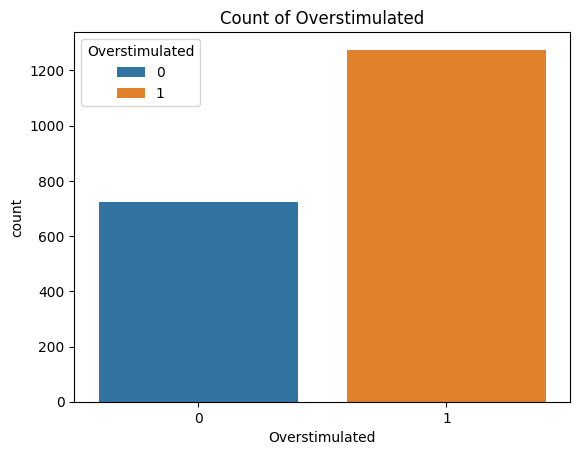

In [41]:
sns.countplot(df, x="Overstimulated", hue="Overstimulated")
plt.title("Count of Overstimulated")
plt.show()

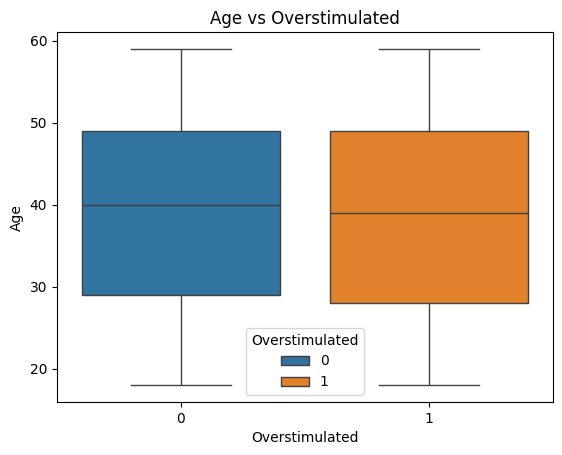

In [45]:
sns.boxplot(df, x="Overstimulated", y="Age", hue="Overstimulated")
plt.title("Age vs Overstimulated")
plt.show()

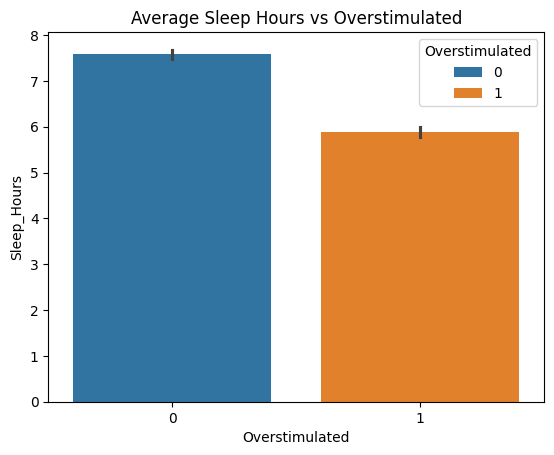

In [46]:
sns.barplot(df, x="Overstimulated", y="Sleep_Hours", hue="Overstimulated")
plt.title("Average Sleep Hours vs Overstimulated")
plt.show()

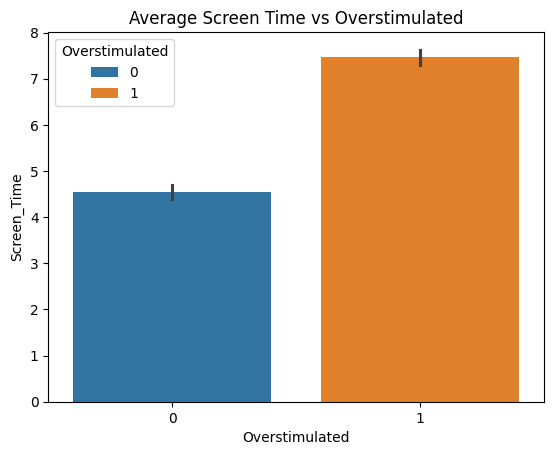

In [47]:
sns.barplot(df, x="Overstimulated", y="Screen_Time", hue="Overstimulated")
plt.title("Average Screen Time vs Overstimulated")
plt.show()

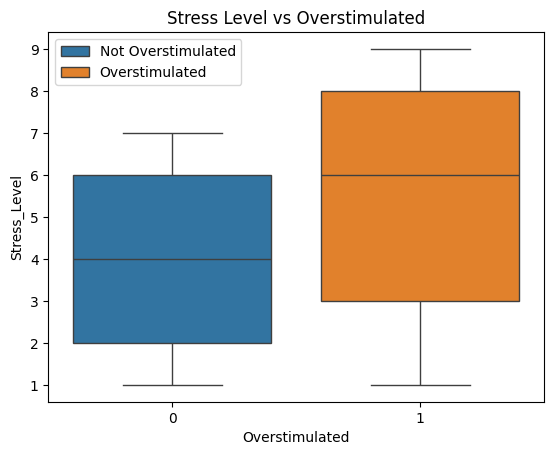

In [52]:
sns.boxplot(df, x="Overstimulated", y="Stress_Level", hue="Overstimulated", legend=False)
plt.legend(["Not Overstimulated", "Overstimulated"])
plt.title("Stress Level vs Overstimulated")
plt.show()

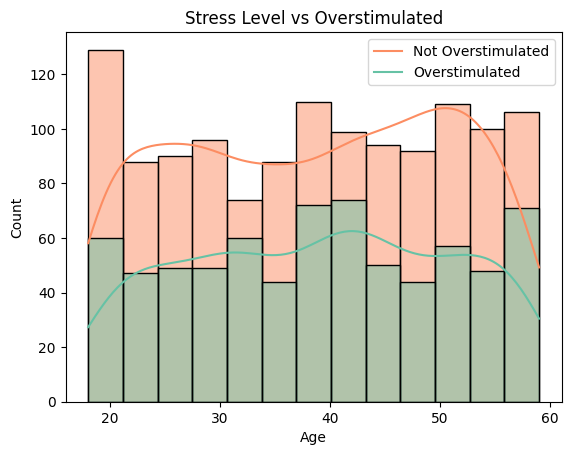

In [91]:
sns.histplot(data=df, x='Age', kde=True, hue='Overstimulated', palette='Set2', legend=False)
plt.legend(["Not Overstimulated", "Overstimulated"])
plt.title("Stress Level vs Overstimulated")
plt.show()

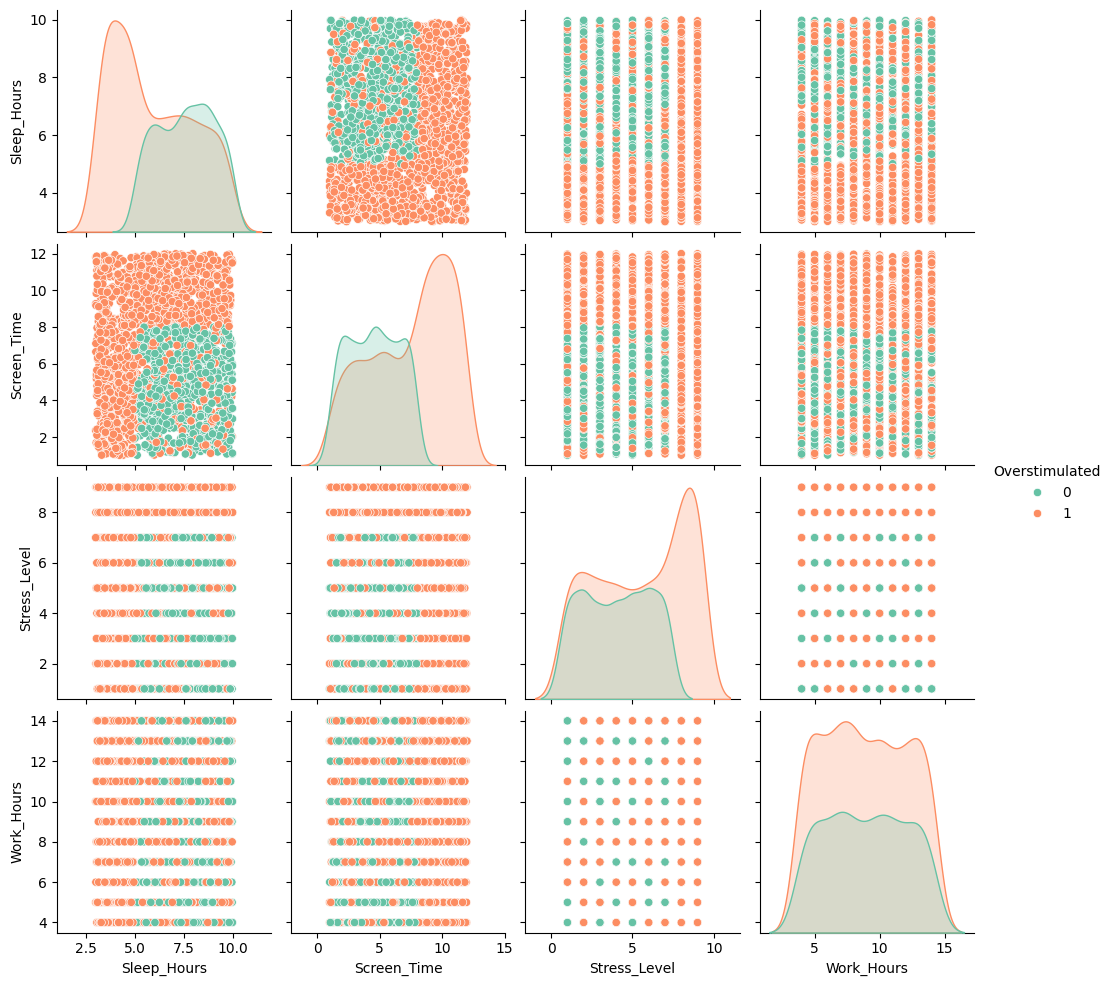

In [41]:
sns.pairplot(df[['Sleep_Hours', 'Screen_Time', 'Stress_Level', 'Work_Hours', 'Overstimulated']], hue='Overstimulated', palette='Set2')

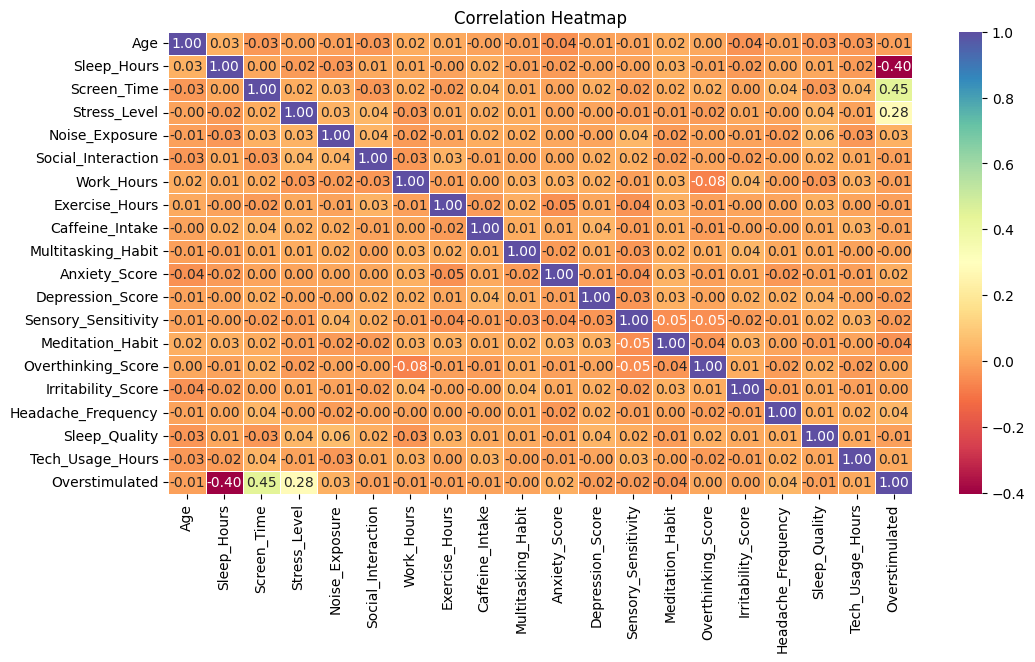

In [12]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(), annot=True, cmap="Spectral", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Using KNN to predict oversitmulation

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

In [64]:
#split dataset
# X = df.iloc[:, 0:19]
# y = df.iloc[:, 19]
X = df.drop('Overstimulated', axis=1)
y = df['Overstimulated']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.2)

In [65]:
#feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [66]:
k_values = [i for i in range (1,31)]
scores = []

scaler = StandardScaler()
X = scaler.fit_transform(X)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X, y, cv=5)
    scores.append(np.mean(score))

Text(0, 0.5, 'Accuracy Score')

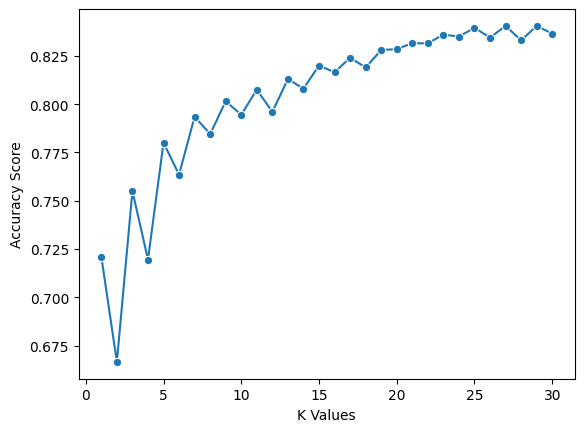

In [67]:
sns.lineplot(x=k_values, y=scores, marker='o')
plt.xlabel("K Values")
plt.ylabel("Accuracy Score")

In [68]:
best_index = np.argmax(scores)
best_k = k_values[best_index]

knn = KNeighborsClassifier(n_neighbors=best_k)

In [69]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=27)

In [70]:
y_pred = knn.predict(X_test)

In [71]:
print(y_pred)

[0 1 1 1 0 1 1 1 1 1 0 0 1 0 0 1 1 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 1
 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 0 1 1 0 1 0 1 1 0 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 0 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 0 1
 1 1 1 0 0 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 0
 0 1 1 1 1 1 1 1 0 1 1 1 0 1 1 0 1 0 1 0 1 1 1 1 0 0 1 1 1 0 0 1 1 1 1 1 1
 0 1 0 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 1 0
 1 1 0 1 1 1 0 1 1 1 0 1 1 1 1 1 0 1 1 1 0 0 1 0 0 1 1 1 0 1 1 0 1 1 0 1 0
 1 0 0 1 1 1 1 0 0 0 0 1 1 1 0 1 1 1 0 1 0 1 1 1 0 0 1 1 0 1 1 1 1 0 1 1 1
 0 0 1 1 1 0 1 1 1 0 1 0 0 0 1 1 0 1 1 0 1 1 0 1 1 1 0 0 1 0 1 1 0 1 1 1 0
 0 1 1 0 1 1 0 1 1 1 1 0 0 1 0 1 0 0 1 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1
 0 1 1 1 0 0 1 0 1 1 1 1 1 0 1 1 0 1 0 1 0 0 0 0 0 1 1 1 1 0]


In [72]:
knn.score(X_test, y_test)

0.845

In [73]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[102  38]
 [ 24 236]]


Text(0.5, 23.52222222222222, 'Predicted label')

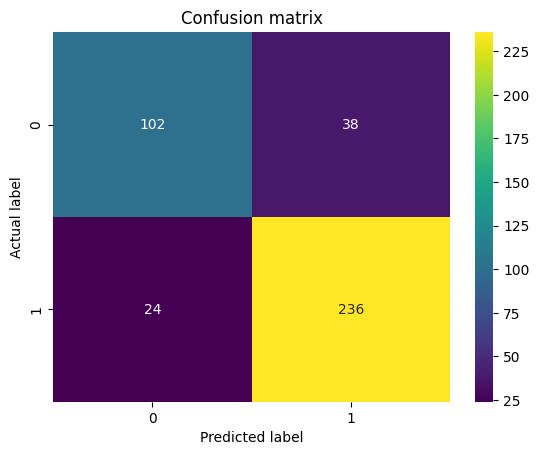

In [74]:
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="viridis", fmt='g')
plt.title('Confusion matrix')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [90]:
print("Classification Report:\n\n", classification_report(y_test, y_pred))

Classification Report:

               precision    recall  f1-score   support

           0       0.81      0.73      0.77       140
           1       0.86      0.91      0.88       260

    accuracy                           0.84       400
   macro avg       0.84      0.82      0.83       400
weighted avg       0.84      0.84      0.84       400



In [76]:
from sklearn.metrics import auc, roc_auc_score, roc_curve

y_pred_proba = knn.predict_proba(X_test)[:,-1]
fpr, tpr, threshold = roc_curve(y_test, y_pred_proba)

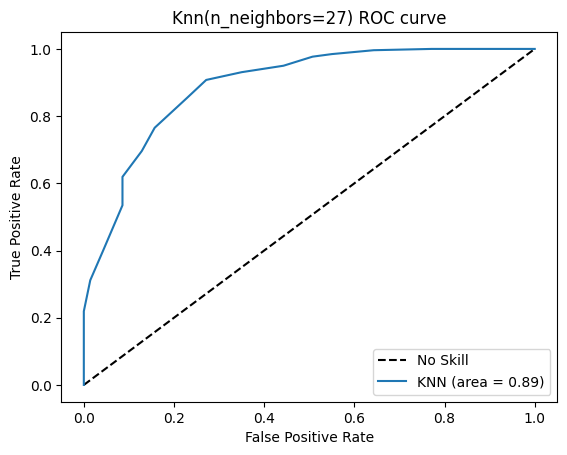

In [88]:
classifier_roc_auc = roc_auc_score(y_test, y_pred_proba)
plt.plot([0,1],[0,1], 'k--', label = "No Skill")

plt.plot(fpr, tpr, label ='KNN (area = %0.2f)' % classifier_roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f'Knn(n_neighbors={best_k}) ROC curve')
plt.legend(loc="lower right", fontsize = "medium")
plt.show()

